# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers , models
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd

# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [4]:
(x_train , y_train) , (x_test , y_test) = tf.keras.datasets.cifar10.load_data()
class_name = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print("Train shape :", x_train.shape)
print("Test shape :" , x_test.shape)

Train shape : (50000, 32, 32, 3)
Test shape : (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

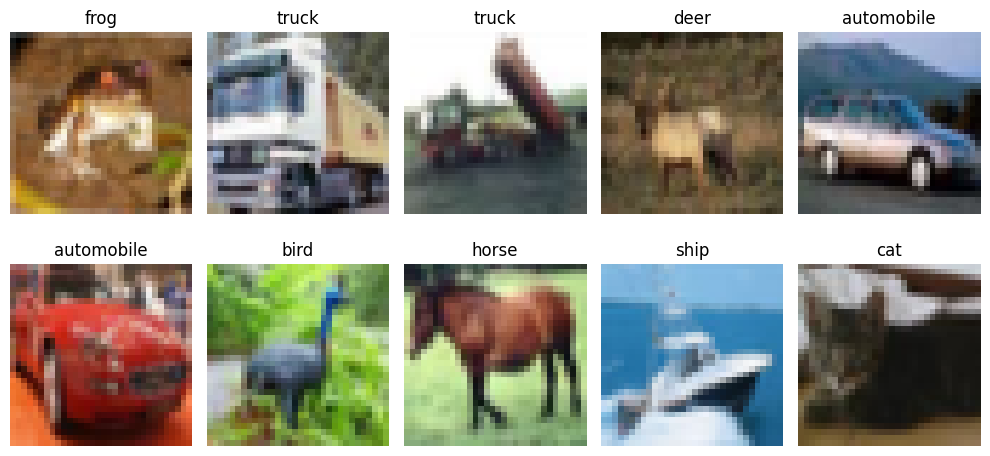

In [5]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_name[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [6]:
x_train_norm = x_train/255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm) , -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm) , -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [7]:
ann_model = models.Sequential([
    layers.Dense(512 , activation = 'relu' , input_shape =(3072 ,)),
    layers.Dropout(0.3),
    layers.Dense(256 , activation='relu'),
    layers.Dense(10 , activation='softmax')
])

ann_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics =['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat ,
    y_train,
    epochs = 10,
    validation_split = 0.1,
    batch_size = 64
)

c:\Users\sumit\Astrophysics\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.2647 - loss: 2.0066 - val_accuracy: 0.3440 - val_loss: 1.8271
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3112 - loss: 1.8810 - val_accuracy: 0.3402 - val_loss: 1.8075
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3265 - loss: 1.8300 - val_accuracy: 0.3574 - val_loss: 1.7586
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3464 - loss: 1.7901 - val_accuracy: 0.3866 - val_loss: 1.7358
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3567 - loss: 1.7657 - val_accuracy: 0.3936 - val_loss: 1.7089
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3694 - loss: 1.7361 - val_accuracy: 0.3986 - val_loss: 1.6881
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3734 - loss: 1.7188 - val_accuracy: 0.4176 - val_loss: 1.6723
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3736 - loss: 1.7111 - 

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4273 - loss: 1.6275
ANN Test Accuracy: 0.42730000615119934


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [9]:
cnn_model = models.Sequential([
    layers.Conv2D(32 ,(3,3) , activation='relu' , input_shape = (32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\sumit\Astrophysics\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.4649 - loss: 1.4983 - val_accuracy: 0.4240 - val_loss: 1.6891
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.6051 - loss: 1.1308 - val_accuracy: 0.6240 - val_loss: 1.0938
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.6684 - loss: 0.9581 - val_accuracy: 0.6272 - val_loss: 1.0896
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.7124 - loss: 0.8282 - val_accuracy: 0.6784 - val_loss: 0.9348
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.7423 - loss: 0.7396 - val_accuracy: 0.6758 - val_loss: 1.0005
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.7710 - loss: 0.6557 - val_accuracy: 0.6786 - val_loss: 0.9532
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.7875 - loss: 0.5969 - val_accuracy: 0.7166 - val_loss: 0.8723
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.8126 - loss: 0.5287 - 

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7217 - loss: 0.9487
CNN Test Accuracy: 0.7217000126838684


## 📈 Compare Learning Curves

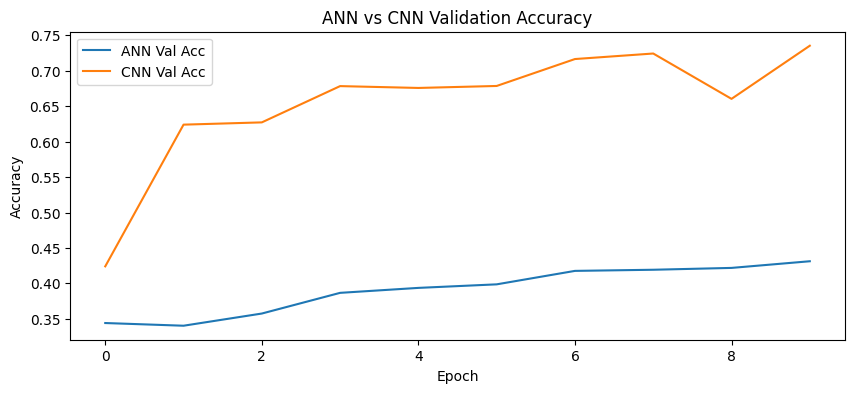

In [11]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [25]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.3736 - loss: 1.7162 - val_accuracy: 0.4644 - val_loss: 1.4580
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.4726 - loss: 1.4606 - val_accuracy: 0.5508 - val_loss: 1.2427
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5123 - loss: 1.3631 - val_accuracy: 0.5764 - val_loss: 1.1862
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5365 - loss: 1.3031 - val_accuracy: 0.6106 - val_loss: 1.0760
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.5537 - loss: 1.2635 - val_accuracy: 0.6126 - val_loss: 1.0864
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.5612 - loss: 1.2371 - val_accuracy: 0.6124 - val_loss: 1.0879
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.5694 - loss: 1.2156 - val_accuracy: 0.6322 - val_loss: 1.0481
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.5788 -

In [27]:
aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print(" AUG CNN Test Accuracy:", aug_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6287 - loss: 1.0538
 AUG CNN Test Accuracy: 0.6287000179290771


# 📊 Final Comparison Table

In [28]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN" ,"AUG_CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc , aug_cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4273
1,CNN,0.7217
2,AUG_CNN,0.6287


### Beginner Tasks
1. Change CNN filters from 32→64→128
2. Increase epochs to 20
3. Add **EarlyStopping**
4. Add **data augmentation training**

In [32]:
# here i am doing data augmentation
data_aug = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

#early stopping 
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# contructing new  cnn model 32->64->128
new_cnn_model = tf.keras.Sequential([
    data_aug,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

#compiling model
new_cnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
#fit the model
history = new_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,# runnig for 20 epochs 
    batch_size=64,
    validation_data=(x_test_norm, y_test),
    callbacks=[early_stop]
)


c:\Users\sumit\Astrophysics\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.4229 - loss: 1.6141 - val_accuracy: 0.4663 - val_loss: 1.4780
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.5202 - loss: 1.3535 - val_accuracy: 0.5151 - val_loss: 1.3834
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - accuracy: 0.5644 - loss: 1.2328 - val_accuracy: 0.5786 - val_loss: 1.2343
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.5955 - loss: 1.1595 - val_accuracy: 0.6075 - val_loss: 1.1328
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 71ms/step - accuracy: 0.6181 - loss: 1.1015 - val_accuracy: 0.6632 - val_loss: 0.9593
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step - accuracy: 0.6331 - loss: 1.0578 - val_accuracy: 0.6474 - val_loss: 1.0361
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step - accuracy: 0.6462 - loss: 1.0202 - val_accuracy: 0.6632 - val_loss: 1.0148
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step - accuracy: 0.6582 - loss: 0.9882 - 

In [33]:
new_cnn_test_loss, new_cnn_test_acc = new_cnn_model.evaluate(x_test_norm, y_test)
print("New CNN Test Accuracy:", new_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6632 - loss: 0.9593
New CNN Test Accuracy: 0.6632000207901001


conclusion for cnn with augmentation i think that the performance should improve when we increase the number of epoch but because of early stopping it stops at 10 epochs means model starts overfitting the data


## Increase ANN layers and observe performance

Conclusion as we increase the later the accuracy of model slightly increase from 43.32 to 44.12

In [ ]:
#increase layer architecure of ann
new_ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),#added
    layers.Dense(32, activation='relu'),#added
    layers.Dense(10, activation='softmax')
])

new_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

new_ann_history = new_ann_model.fit(
    x_train_flat,
    y_train,
    epochs=10, 
    validation_split=0.1,
    batch_size=64
)

c:\Users\sumit\Astrophysics\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.2287 - loss: 2.0573 - val_accuracy: 0.3212 - val_loss: 1.8705
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3165 - loss: 1.8748 - val_accuracy: 0.3388 - val_loss: 1.8203
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3409 - loss: 1.8102 - val_accuracy: 0.3668 - val_loss: 1.7543
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3583 - loss: 1.7714 - val_accuracy: 0.3898 - val_loss: 1.7245
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3697 - loss: 1.7371 - val_accuracy: 0.3984 - val_loss: 1.6981
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3827 - loss: 1.7116 - val_accuracy: 0.4124 - val_loss: 1.6809
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3900 - loss: 1.6863 - val_accuracy: 0.4228 - val_loss: 1.6522
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3971 - loss: 1.6678 - 

In [41]:
new_ann_test_loss, new_ann_test_acc = new_ann_model.evaluate(x_test_flat, y_test)
print("New ANN Test Accuracy:", new_ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4363 - loss: 1.5853
New ANN Test Accuracy: 0.43630000948905945


In [48]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "ANN (Old)",
        "ANN (New)",
        "CNN (Old)",
        "CNN (New)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        new_ann_test_acc,
        cnn_test_acc,
        new_cnn_test_acc
    ],
    "Validation Accuracy": [
        ann_history.history['val_accuracy'][-1],
        new_ann_history.history['val_accuracy'][-1],
        cnn_history.history['val_accuracy'][-1],
        history.history['val_accuracy'][-1]
    ]
})

comparison = comparison.sort_values(by="Test Accuracy", ascending=False)

comparison

,Model,Test Accuracy,Validation Accuracy
2,CNN (Old),0.7217,0.7354
3,CNN (New),0.6632,0.5351
1,ANN (New),0.4363,0.4412
0,ANN (Old),0.4273,0.4312


# Overall Result Ranking

1. CNN (Old) — Best performance  
2. CNN (New) — Moderate performance  
3. ANN (New) — Slight improvement over old ANN  
4. ANN (Old) — Lowest performance  

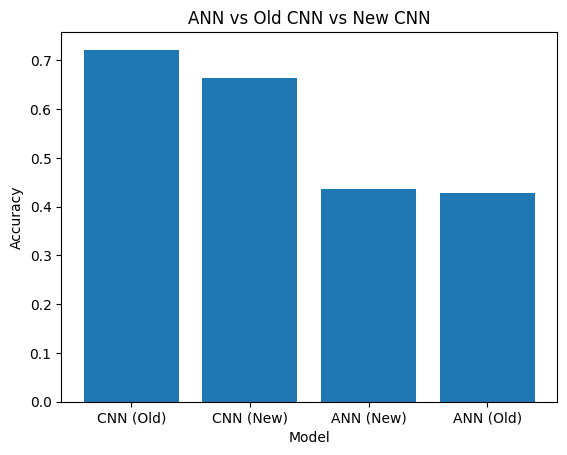

In [ ]:
#data visulaization for better understanding
plt.figure()
plt.bar(comparison["Model"], comparison["Test Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("ANN vs Old CNN vs New CNN")
plt.show()

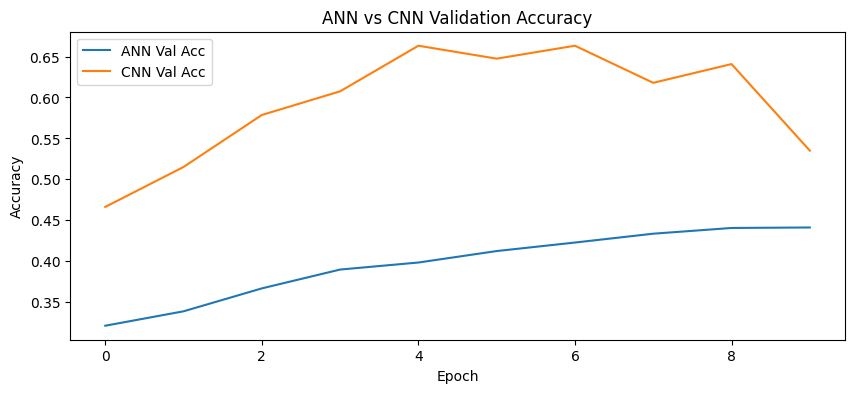

In [49]:
plt.figure(figsize=(10,4))
plt.plot(new_ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()